# Assistify — Bilingual Sentiment Analysis (Arabic + English)
**Model:** MARBERT fine-tuned on Egyptian Arabic + English tweets  
**Baseline:** TF-IDF + Logistic Regression  
**Classes:** Negative | Positive | Neutral  

In [1]:
!pip install transformers datasets torch scikit-learn matplotlib seaborn langdetect -q
!pip install datasets --upgrade -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 58.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 31.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 20.1 MB/s eta 0:00:00


In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from langdetect import detect

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.pipeline import Pipeline

import torch
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer, DataCollatorWithPadding
)
from datasets import Dataset

plt.rcParams['figure.dpi'] = 120
SEED = 42
np.random.seed(SEED)

print('Imports done ✓')
print(f'PyTorch: {torch.__version__} | GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"}')

Imports done ✓
PyTorch: 2.11.0+cu128 | GPU: Tesla T4


## 1. Data Loading

In [3]:
df_ar = pd.read_csv('40000-Egyptian-tweets-v2.csv')
df_ar['lang'] = 'ar'
print(f'Arabic raw: {df_ar.shape}')

df_en = pd.read_excel('/content/balanced_data (1).xlsx', header=None, names=['label', 'review'])
df_en = df_en.iloc[1:].reset_index(drop=True)
df_en['lang'] = 'en'
print(f'English raw: {df_en.shape}')

Arabic raw: (54983, 3)
English raw: (44949, 3)


## 2. EDA

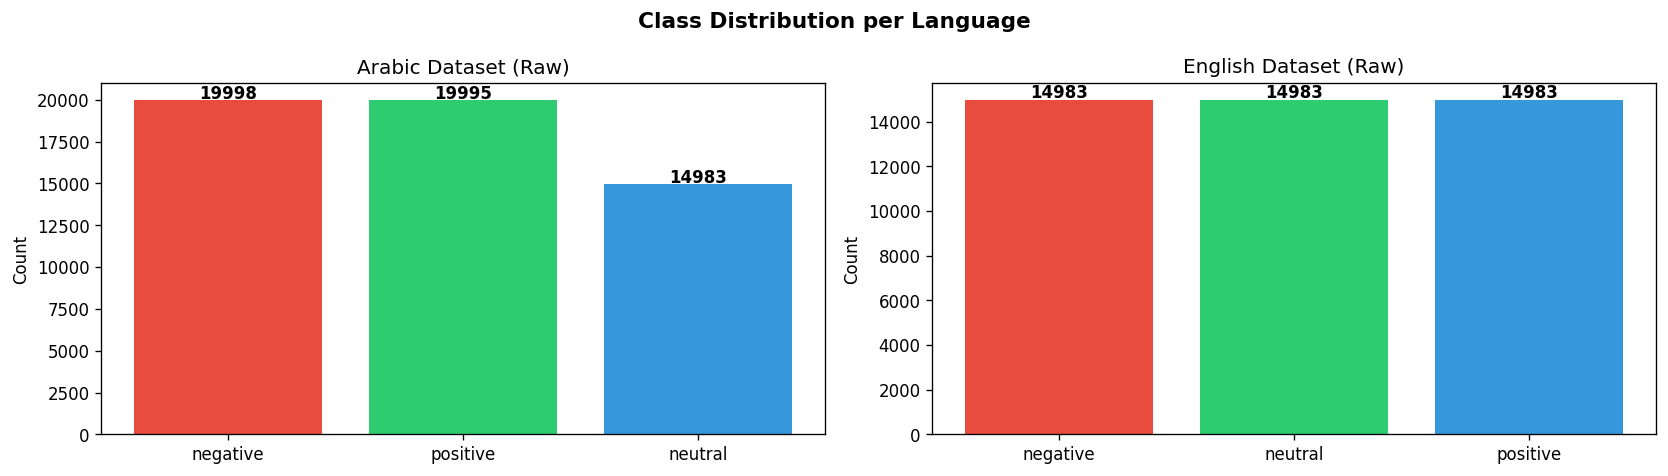

In [5]:
CLEAN_LABELS = {'negative', 'positive', 'neutral'}

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
colors = ['#e74c3c', '#2ecc71', '#3498db']

for ax, df_plot, title in zip(
    axes,
    [df_ar, df_en],
    ['Arabic Dataset (Raw)', 'English Dataset (Raw)']
):
    counts = df_plot[df_plot['label'].isin(CLEAN_LABELS)]['label'].value_counts()
    ax.bar(counts.index, counts.values, color=colors)
    ax.set_title(title)
    ax.set_ylabel('Count')
    for i, v in enumerate(counts.values):
        ax.text(i, v + 80, str(v), ha='center', fontweight='bold')

plt.suptitle('Class Distribution per Language', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_distribution.png', bbox_inches='tight')
plt.show()

## 3. Data Cleaning

In [6]:
def fix_label(label):
    if not isinstance(label, str):
        return None
    cleaned = re.sub(r'[\u200b-\u200f\u202a-\u202e\ufeff\u00a0]', '', label).strip()
    for core in ['negative', 'positive', 'neutral']:
        if core in cleaned:
            return core
    return None

df_ar['label'] = df_ar['label'].apply(fix_label)
df_en['label'] = df_en['label'].apply(fix_label)

df_ar['text_len'] = df_ar['review'].str.len()
df_en['text_len'] = df_en['review'].str.len()

for name, df_ in [('Arabic', df_ar), ('English', df_en)]:
    before = len(df_)
    df_.dropna(subset=['label', 'review'], inplace=True)
    df_.drop_duplicates(subset=['review'], inplace=True)
    df_ = df_[df_['text_len'] >= 5]
    print(f'{name}: {before} → {len(df_)} rows')

df_ar = df_ar[df_ar['text_len'] >= 5].drop_duplicates(subset=['review']).dropna(subset=['label'])
df_en = df_en[df_en['text_len'] >= 5].drop_duplicates(subset=['review']).dropna(subset=['label'])

print(f'\nArabic: {df_ar.shape} | English: {df_en.shape}')

Arabic: 54983 → 54660 rows
English: 44949 → 41918 rows

Arabic: (54660, 4) | English: (41918, 4)


In [8]:
df_ar_bal

,review,lang,text_len
0,محتاجين التنهيده اللي تجي من قلب بعد خبر حلو .,ar,46
1,من أعظم الهدايا التي يمكنك إهدائها للشخص هي ...,ar,63
2,ضعيف جدا. السرير مريح وغير ذاك غير مريح. المكا...,ar,209
3,وبعدين في ابن خالتي اللي بيقلدنى في كل حاجة ده .,ar,49
4,“شقق الحمراء”. للاسف خدمات الفندق. شقق مفروشه ...,ar,105
...,...,...,...
44944,تطور الشعب عمرة ما يتحقق طول ما الاشكال الوسخة...,ar,72
44945,ادعوا معايا يارب نحس المنتخب يتفك النهارده .,ar,46
44946,عند قوله تعالى اقرا كتابك كفى بنفسك اليوم عليك...,ar,130
44947,اللي كان بيكوي فلوسه وهو صغير عشان تطلع جديدة ...,ar,68


In [9]:
def undersample(df):
    min_count = df['label'].value_counts().min()
    df_bal = (df.groupby('label', group_keys=False)
                .apply(lambda x: x.sample(min_count, random_state=SEED)))
    return df_bal.sample(frac=1, random_state=SEED).reset_index(drop=True)

df_ar_bal = undersample(df_ar)
df_en_bal = undersample(df_en)

print('Arabic balanced:', df_ar_bal['label'].value_counts().to_dict())
print('English balanced:', df_en_bal['label'].value_counts().to_dict())

Arabic balanced: {'positive': 14983, 'neutral': 14983, 'negative': 14983}
English balanced: {'negative': 13808, 'neutral': 13808, 'positive': 13808}


/tmp/ipykernel_891/3406307689.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min_count, random_state=SEED)))
/tmp/ipykernel_891/3406307689.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min_count, random_state=SEED)))


In [10]:
df_combined = pd.concat(
    [df_ar_bal[['review', 'label', 'lang']],
     df_en_bal[['review', 'label', 'lang']]],
    ignore_index=True
).sample(frac=1, random_state=SEED).reset_index(drop=True)

print(f'Combined shape: {df_combined.shape}')
print(df_combined['label'].value_counts())
print()
print(df_combined['lang'].value_counts())

Combined shape: (86373, 3)
label
positive    28791
negative    28791
neutral     28791
Name: count, dtype: int64

lang
ar    44949
en    41424
Name: count, dtype: int64


## 4. Text Preprocessing

In [11]:
def clean_arabic(text):
    if not isinstance(text, str):
        return ''
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'@\w+|#', '', text)
    text = re.sub('[إأآا]', 'ا', text)
    text = re.sub('ى', 'ي', text)
    text = re.sub('ؤ', 'ء', text)
    text = re.sub('ئ', 'ء', text)
    text = re.sub('ة', 'ه', text)
    text = re.sub('گ', 'ك', text)
    text = re.sub(r'[`÷×؛<>_()*&^%\][ـ،/:"؟.,\'{}~+=\\\-a-zA-Z0-9]', ' ', text)
    text = re.sub(r'(.)\1+', r'\1\1', text)
    return ' '.join(text.split())

def clean_english(text):
    if not isinstance(text, str):
        return ''
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'@\w+|#', '', text)
    text = re.sub(r'[^\w\s!?.,]', ' ', text)
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)
    return ' '.join(text.split()).lower()

def preprocess(row):
    if row['lang'] == 'ar':
        return clean_arabic(row['review'])
    return clean_english(row['review'])

df_combined['clean_text'] = df_combined.apply(preprocess, axis=1)
df_combined = df_combined[df_combined['clean_text'].str.strip().ne('')]

print(f'After preprocessing: {df_combined.shape}')
print('\nSample:')
for _, row in df_combined.sample(4, random_state=SEED).iterrows():
    print(f'  [{row["lang"]}][{row["label"]}] {row["clean_text"][:80]}')

After preprocessing: (86349, 4)

Sample:
  [en][negative] problems . rampant sexual assualt in educational institutes.. pia fake licenses.
  [en][negative] they are all wrong so big as minecraft exists
  [ar][positive] لو حياتي كانت كتاب وانا المءلف بتاعه كنت هكتبه عن الحريه وعن الاستمتاع الصح بيها
  [en][positive] every time round i see new content from and i get more hyped off and literally s


In [12]:
LABEL2ID = {'negative': 0, 'positive': 1, 'neutral': 2}
ID2LABEL = {v: k for k, v in LABEL2ID.items()}
df_combined['label_id'] = df_combined['label'].map(LABEL2ID)

X_temp, X_test, y_temp, y_test = train_test_split(
    df_combined['clean_text'], df_combined['label_id'],
    test_size=0.15, random_state=SEED, stratify=df_combined['label_id']
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.1765, random_state=SEED, stratify=y_temp
)

print(f'Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}')
print(f'Label dist in test: {Counter(y_test.tolist())}')

Train: 60441 | Val: 12955 | Test: 12953
Label dist in test: Counter({1: 4318, 0: 4318, 2: 4317})


## 5. Baseline — TF-IDF + Logistic Regression

In [13]:
lr_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        analyzer='char_wb',
        ngram_range=(2, 5),
        max_features=100_000,
        sublinear_tf=True
    )),
    ('clf', LogisticRegression(
        C=5.0, max_iter=1000,
        class_weight='balanced',
        random_state=SEED, n_jobs=-1
    ))
])

lr_pipeline.fit(X_train, y_train)
y_pred_lr = lr_pipeline.predict(X_test)

lr_acc = accuracy_score(y_test, y_pred_lr)
lr_f1  = f1_score(y_test, y_pred_lr, average='weighted')

print('=== TF-IDF + Logistic Regression (Baseline) ===')
print(f'Accuracy: {lr_acc:.4f} | Weighted F1: {lr_f1:.4f}')
print()
print(classification_report(y_test, y_pred_lr, target_names=['negative', 'positive', 'neutral']))

=== TF-IDF + Logistic Regression (Baseline) ===
Accuracy: 0.8428 | Weighted F1: 0.8433

              precision    recall  f1-score   support

    negative       0.81      0.82      0.81      4318
    positive       0.81      0.82      0.82      4318
     neutral       0.91      0.89      0.90      4317

    accuracy                           0.84     12953
   macro avg       0.84      0.84      0.84     12953
weighted avg       0.84      0.84      0.84     12953



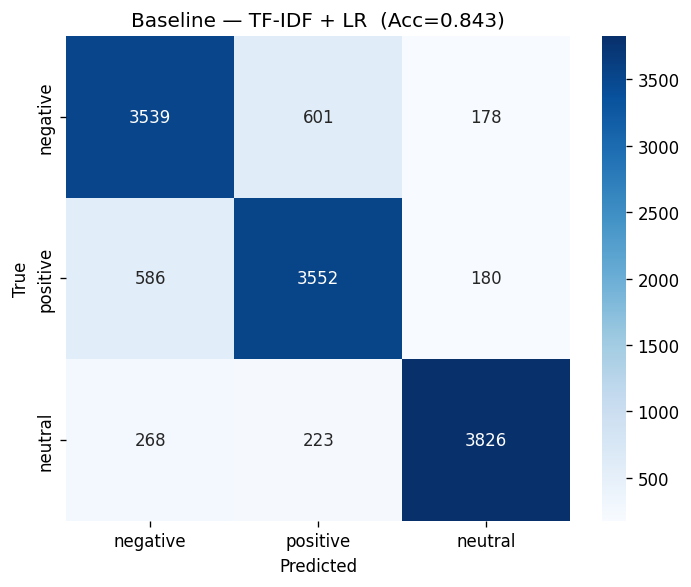

In [14]:
cm_lr = confusion_matrix(y_test, y_pred_lr)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=['negative', 'positive', 'neutral'],
            yticklabels=['negative', 'positive', 'neutral'], ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title(f'Baseline — TF-IDF + LR  (Acc={lr_acc:.3f})')
plt.tight_layout()
plt.savefig('cm_baseline.png', bbox_inches='tight')
plt.show()

## 6. MARBERT Fine-Tuning

In [15]:
MODEL_NAME = 'UBC-NLP/MARBERT'
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print('Tokenizer loaded ✓')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/701 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/376 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/1.10M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Tokenizer loaded ✓


In [16]:
def make_dataset(texts, labels):
    return Dataset.from_dict({
        'text': list(texts),
        'labels': list(labels.astype(int))
    })

ds_train = make_dataset(X_train, y_train)
ds_val   = make_dataset(X_val,   y_val)
ds_test  = make_dataset(X_test,  y_test)

def tokenize_fn(batch):
    return tokenizer(
        batch['text'],
        padding='max_length',
        truncation=True,
        max_length=128
    )

ds_train = ds_train.map(tokenize_fn, batched=True)
ds_val   = ds_val.map(tokenize_fn,   batched=True)
ds_test  = ds_test.map(tokenize_fn,  batched=True)

print(f'Train: {len(ds_train)} | Val: {len(ds_val)} | Test: {len(ds_test)}')

Map:   0%|          | 0/60441 [00:00<?, ? examples/s]

Map:   0%|          | 0/12955 [00:00<?, ? examples/s]

Map:   0%|          | 0/12953 [00:00<?, ? examples/s]

Train: 60441 | Val: 12955 | Test: 12953


In [17]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    id2label=ID2LABEL,
    label2id=LABEL2ID
)
print(f'Model: {sum(p.numel() for p in model.parameters())/1e6:.1f}M params')

pytorch_model.bin:   0%|          | 0.00/654M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: UBC-NLP/MARBERT
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider

Model: 162.8M params


In [18]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        'accuracy':     accuracy_score(labels, preds),
        'f1_weighted':  f1_score(labels, preds, average='weighted'),
        'f1_macro':     f1_score(labels, preds, average='macro'),
    }

training_args = TrainingArguments(
    output_dir='./marbert_bilingual',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_steps=500,
    lr_scheduler_type='linear',
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1_weighted',
    fp16=torch.cuda.is_available(),
    seed=SEED,
    logging_steps=200,
    report_to='none'
)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=ds_train,
    eval_dataset=ds_val,
    compute_metrics=compute_metrics,
    data_collator=data_collator
)

print('Trainer ready ✓')

Trainer ready ✓


In [19]:
train_result = trainer.train()
print(train_result)

Epoch,Training Loss,Validation Loss,Accuracy,F1 Weighted,F1 Macro
1,0.411165,0.415093,0.836897,0.836970,0.836973
2,0.244297,0.357774,0.883211,0.883295,0.883299
3,0.149547,0.483958,0.898881,0.899001,0.899005


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=11334, training_loss=0.32454811481228785, metrics={'train_runtime': 1800.4969, 'train_samples_per_second': 100.707, 'train_steps_per_second': 6.295, 'total_flos': 1.1927128560673536e+16, 'train_loss': 0.32454811481228785, 'epoch': 3.0})


## 7. Evaluation & Comparison

In [20]:
test_results = trainer.predict(ds_test)
y_pred_marbert = np.argmax(test_results.predictions, axis=1)

marbert_acc = accuracy_score(y_test, y_pred_marbert)
marbert_f1  = f1_score(y_test, y_pred_marbert, average='weighted')

print('=== MARBERT Fine-tuned (Bilingual) ===')
print(f'Accuracy: {marbert_acc:.4f} | Weighted F1: {marbert_f1:.4f}')
print()
print(classification_report(y_test, y_pred_marbert, target_names=['negative', 'positive', 'neutral']))

=== MARBERT Fine-tuned (Bilingual) ===
Accuracy: 0.8978 | Weighted F1: 0.8980

              precision    recall  f1-score   support

    negative       0.87      0.89      0.88      4318
    positive       0.88      0.89      0.89      4318
     neutral       0.94      0.91      0.93      4317

    accuracy                           0.90     12953
   macro avg       0.90      0.90      0.90     12953
weighted avg       0.90      0.90      0.90     12953



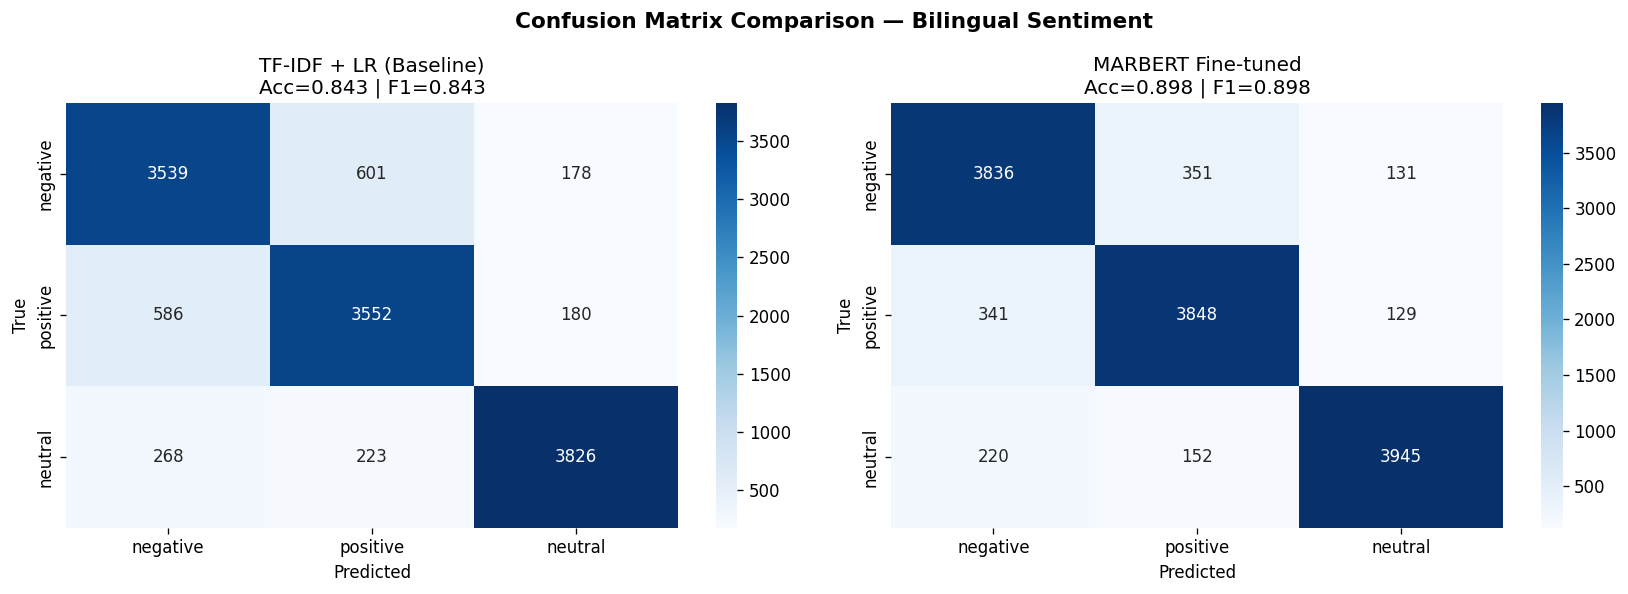

In [21]:
cm_marbert = confusion_matrix(y_test, y_pred_marbert)
class_names = ['negative', 'positive', 'neutral']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, cm, title in zip(
    axes,
    [cm_lr, cm_marbert],
    [f'TF-IDF + LR (Baseline)\nAcc={lr_acc:.3f} | F1={lr_f1:.3f}',
     f'MARBERT Fine-tuned\nAcc={marbert_acc:.3f} | F1={marbert_f1:.3f}']
):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names,
                yticklabels=class_names, ax=ax)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_title(title)

plt.suptitle('Confusion Matrix Comparison — Bilingual Sentiment', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrices.png', bbox_inches='tight')
plt.show()

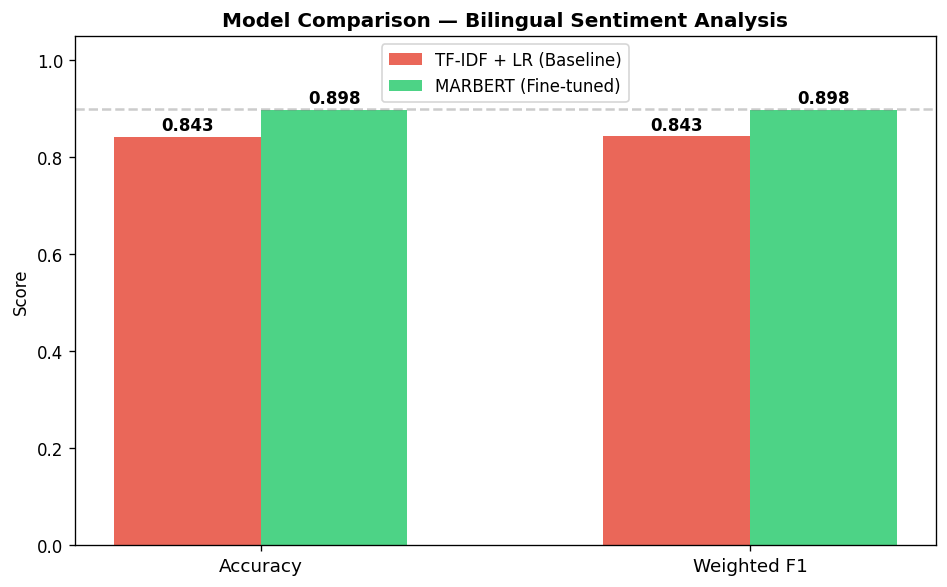

In [22]:
metrics  = {'Accuracy': [lr_acc, marbert_acc], 'Weighted F1': [lr_f1, marbert_f1]}
models   = ['TF-IDF + LR (Baseline)', 'MARBERT (Fine-tuned)']
colors   = ['#e74c3c', '#2ecc71']
x = np.arange(len(metrics))
width = 0.3

fig, ax = plt.subplots(figsize=(8, 5))
for i, (model_name, color) in enumerate(zip(models, colors)):
    vals = [metrics[m][i] for m in metrics]
    bars = ax.bar(x + i * width, vals, width, label=model_name, color=color, alpha=0.85)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xticks(x + width / 2)
ax.set_xticklabels(list(metrics.keys()), fontsize=11)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('Model Comparison — Bilingual Sentiment Analysis', fontweight='bold')
ax.legend()
ax.axhline(0.9, linestyle='--', color='gray', alpha=0.4)
plt.tight_layout()
plt.savefig('model_comparison.png', bbox_inches='tight')
plt.show()

## 8. Error Analysis

In [23]:
test_texts = X_test.reset_index(drop=True)
error_df = pd.DataFrame({
    'text':       test_texts,
    'true_label': [ID2LABEL[i] for i in y_test.values],
    'pred_label': [ID2LABEL[i] for i in y_pred_marbert]
})
errors = error_df[error_df['true_label'] != error_df['pred_label']].copy()
print(f'Misclassified: {len(errors)} / {len(error_df)} ({len(errors)/len(error_df)*100:.1f}%)')
print()
errors['error_type'] = errors['true_label'] + ' → ' + errors['pred_label']
print('Most common error patterns:')
print(errors['error_type'].value_counts().head(8))

Misclassified: 1324 / 12953 (10.2%)

Most common error patterns:
error_type
negative → positive    351
positive → negative    341
neutral → negative     220
neutral → positive     152
negative → neutral     131
positive → neutral     129
Name: count, dtype: int64


In [24]:
print('Per-class error rates:')
for lbl in ['negative', 'positive', 'neutral']:
    total = (error_df['true_label'] == lbl).sum()
    wrong = ((error_df['true_label'] == lbl) & (error_df['pred_label'] != lbl)).sum()
    print(f'  {lbl:10s}: {wrong}/{total} = {wrong/total*100:.1f}%')

Per-class error rates:
  negative  : 482/4318 = 11.2%
  positive  : 470/4318 = 10.9%
  neutral   : 372/4317 = 8.6%


## 9. Save & Upload to HuggingFace

In [25]:
SAVE_DIR = './marbert_bilingual_final'
trainer.save_model(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)
print(f'Model saved to {SAVE_DIR} ✓')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to ./marbert_bilingual_final ✓


In [ ]:
from huggingface_hub import login
import os

login('')

model.push_to_hub('jehadMahmoud/Sentiment_analysis_Final')
tokenizer.push_to_hub('jehadMahmoud/Sentiment_analysis_Final')
print('Uploaded ✓ → https://huggingface.co/jehadMahmoud/Sentiment_analysis_Final')

README.md:   0%|          | 0.00/5.17k [00:00<?, ?B/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...xbb9rz6/model.safetensors:   0%|          |  555kB /  651MB            

No files have been modified since last commit. Skipping to prevent empty commit.


Uploaded ✓ → https://huggingface.co/jehadMahmoud/Sentiment_analysis_Final
